<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Linear-Algebra/blob/main/12_Least_Squares_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Least Squares Applications**

This notebook covers Least Squares Applications:
1. Predicting Bike Rentals Based on Weather
2. Regression Table Using Statsmodels
3. Multicollinearity
4. Regularization
5. Polynomial Regression
6. Grid Search for Model Parameters
7. Summary


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 8)

## **1. Predicting Bike Rentals Based on Weather**

Bike rental demand prediction is a classic regression problem in machine learning and data science. The goal is to predict how many bicycles will be rented on a given day based on weather conditions and temporal factors. This real-world problem demonstrates how least squares methods can be applied to understand and forecast demand in shared mobility systems.

### **Creating Synthetic Data**

For this example, we create a synthetic dataset that captures realistic relationships between weather conditions and bike rental demand. In practice, this data would come from actual bike rental systems like Citi Bike, Capital Bikeshare, or other shared mobility platforms.

In [2]:
# Create synthetic bike rental dataset
n_samples = 200
np.random.seed(42)

# Generate features (weather and temporal factors)
temperature = np.random.uniform(5, 35, n_samples)  # Celsius
humidity = np.random.uniform(20, 90, n_samples)  # Percentage
wind_speed = np.random.uniform(0, 30, n_samples)  # km/h
is_holiday = np.random.binomial(1, 0.1, n_samples)  # Binary

# Create target variable with realistic relationships
# Bike rentals increase with temperature, decrease with humidity and wind
bike_rentals = (50 +
                2.5 * temperature -
                0.5 * humidity -
                1.0 * wind_speed +
                30 * is_holiday +
                np.random.normal(0, 20, n_samples))

# Ensure no negative values
bike_rentals = np.maximum(bike_rentals, 0)

# Create DataFrame
data = pd.DataFrame({
    'Temperature': temperature,
    'Humidity': humidity,
    'Wind_Speed': wind_speed,
    'Is_Holiday': is_holiday,
    'Bike_Rentals': bike_rentals
})

print('Bike Rental Dataset')
print('=' * 70)
print(f'Shape: {data.shape}')
print(f'\nFirst few rows:')
print(data.head())
print(f'\nDescriptive Statistics:')
print(data.describe())

Bike Rental Dataset
Shape: (200, 5)

First few rows:
   Temperature   Humidity  Wind_Speed  Is_Holiday  Bike_Rentals
0    16.236204  64.942215    3.093716           0     39.216196
1    33.521429  25.889798   27.076587           0    103.211454
2    26.959818  31.314010   15.157571           0    124.225459
3    22.959755  82.898793   24.793724           0     68.064667
4     9.680559  62.450034    9.601488           0     65.238625

Descriptive Statistics:
       Temperature    Humidity  Wind_Speed  Is_Holiday  Bike_Rentals
count   200.000000  200.000000  200.000000  200.000000    200.000000
mean     19.520187   55.306260   15.620184    0.075000     58.039473
std       8.846743   20.510083    9.219264    0.264052     34.014835
min       5.165664   20.354311    0.325130    0.000000      0.000000
25%      11.857472   38.302375    7.665609    0.000000     32.206270
50%      19.834588   57.914791   15.761984    0.000000     60.180138
75%      27.705788   71.953952   24.333447    0.000000 

## **2. Regression Table Using Statsmodels**

While NumPy and SciPy provide the basic numerical tools for least squares fitting, the statsmodels library provides comprehensive statistical summaries of regression models. The regression table includes coefficient estimates, standard errors, t-statistics, p-values, and model fit statistics like R-squared and adjusted R-squared.

### **Interpreting Model Output**

The regression table provides detailed information about:
- **Coefficient estimates**: The fitted values βᵢ
- **Standard errors**: Uncertainty in coefficient estimates
- **t-statistics**: Coefficient / Standard Error
- **p-values**: Statistical significance of coefficients
- **R-squared**: Proportion of variance explained
- **Adjusted R-squared**: R² adjusted for number of predictors
- **F-statistic**: Overall model significance

In [3]:
# Prepare features and target
X = data[['Temperature', 'Humidity', 'Wind_Speed', 'Is_Holiday']].values
y = data['Bike_Rentals'].values

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

print('BASIC LINEAR REGRESSION MODEL')
print('=' * 70)
print(f'Intercept: {model.intercept_:.4f}')
print(f'\nCoefficients:')
feature_names = ['Temperature', 'Humidity', 'Wind_Speed', 'Is_Holiday']
for name, coef in zip(feature_names, model.coef_):
    print(f'  {name}: {coef:8.4f}')

# Predictions
y_pred = model.predict(X)

# Calculate R-squared
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print(f'\nModel Performance:')
print(f'  R² Score: {r2:.4f}')
print(f'  RMSE: {rmse:.4f}')
print(f'  MAE: {mae:.4f}')

# Adjusted R-squared
n = len(y)
p = X.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'  Adjusted R²: {adjusted_r2:.4f}')

BASIC LINEAR REGRESSION MODEL
Intercept: 52.8157

Coefficients:
  Temperature:   2.6593
  Humidity:  -0.5870
  Wind_Speed:  -1.0217
  Is_Holiday:  23.2017

Model Performance:
  R² Score: 0.6915
  RMSE: 18.8468
  MAE: 14.8455
  Adjusted R²: 0.6851


## **3. Multicollinearity**

### **What is Multicollinearity?**

Multicollinearity occurs when predictor variables are highly correlated with each other. This causes problems for least squares estimation:

1. **Inflated Standard Errors**: Uncertainty in coefficient estimates increases
2. **Unstable Coefficients**: Small changes in data cause large changes in estimates
3. **Reduced Interpretability**: Hard to assess individual variable importance
4. **Overfitting Risk**: Model may fit training data well but generalize poorly

### **Detecting Multicollinearity**

The **Variance Inflation Factor (VIF)** quantifies how much the variance of a coefficient estimate is inflated due to multicollinearity. VIF = 1 indicates no correlation; VIF > 5-10 suggests problematic multicollinearity.

VIF is computed as: VIF_j = 1 / (1 - R²_j)

where R²_j is the R² from regressing predictor j on all other predictors.

In [4]:
# Calculate correlation matrix
correlation_matrix = data[feature_names].corr()

print('MULTICOLLINEARITY ANALYSIS')
print('=' * 70)
print('\nCorrelation Matrix:')
print(correlation_matrix.round(3))

# Calculate VIF for each variable
vif_values = []
for i in range(X.shape[1]):
    X_other = np.delete(X, i, axis=1)
    model_temp = LinearRegression().fit(X_other, X[:, i])
    y_pred_temp = model_temp.predict(X_other)
    r2_temp = r2_score(X[:, i], y_pred_temp)
    vif = 1 / (1 - max(0.9999, r2_temp))
    vif_values.append(vif)

print('\nVariance Inflation Factors (VIF):')
for name, vif in zip(feature_names, vif_values):
    status = '✓ Low' if vif < 5 else '⚠ High' if vif < 10 else '✗ Very High'
    print(f'  {name:15s}: {vif:8.3f} ({status})')

print('\nVIF Interpretation:')
print('  VIF = 1: No correlation with other predictors')
print('  VIF < 5: Generally acceptable')
print('  VIF > 10: Problematic multicollinearity')

MULTICOLLINEARITY ANALYSIS

Correlation Matrix:
             Temperature  Humidity  Wind_Speed  Is_Holiday
Temperature        1.000    -0.027      -0.046      -0.038
Humidity          -0.027     1.000      -0.124       0.149
Wind_Speed        -0.046    -0.124       1.000      -0.006
Is_Holiday        -0.038     0.149      -0.006       1.000

Variance Inflation Factors (VIF):
  Temperature    : 10000.000 (✗ Very High)
  Humidity       : 10000.000 (✗ Very High)
  Wind_Speed     : 10000.000 (✗ Very High)
  Is_Holiday     : 10000.000 (✗ Very High)

VIF Interpretation:
  VIF = 1: No correlation with other predictors
  VIF < 5: Generally acceptable
  VIF > 10: Problematic multicollinearity


## **4. Regularization**

Regularization techniques address multicollinearity and overfitting by adding a penalty term to the least squares objective function. Instead of minimizing only the sum of squared residuals, we minimize:

Cost = ||y - Xβ||² + λ × Penalty(β)

where λ is the regularization strength and Penalty depends on the regularization type.

### **Types of Regularization**

**Ridge Regression (L2 Regularization)**
- Penalty: λ × ||β||² (sum of squared coefficients)
- Shrinks all coefficients proportionally
- Never eliminates variables

**Lasso Regression (L1 Regularization)**
- Penalty: λ × ||β|| (sum of absolute values)
- Can shrink coefficients to exactly zero
- Performs automatic feature selection

**Elastic Net**
- Combination of Ridge and Lasso
- Balances benefits of both approaches

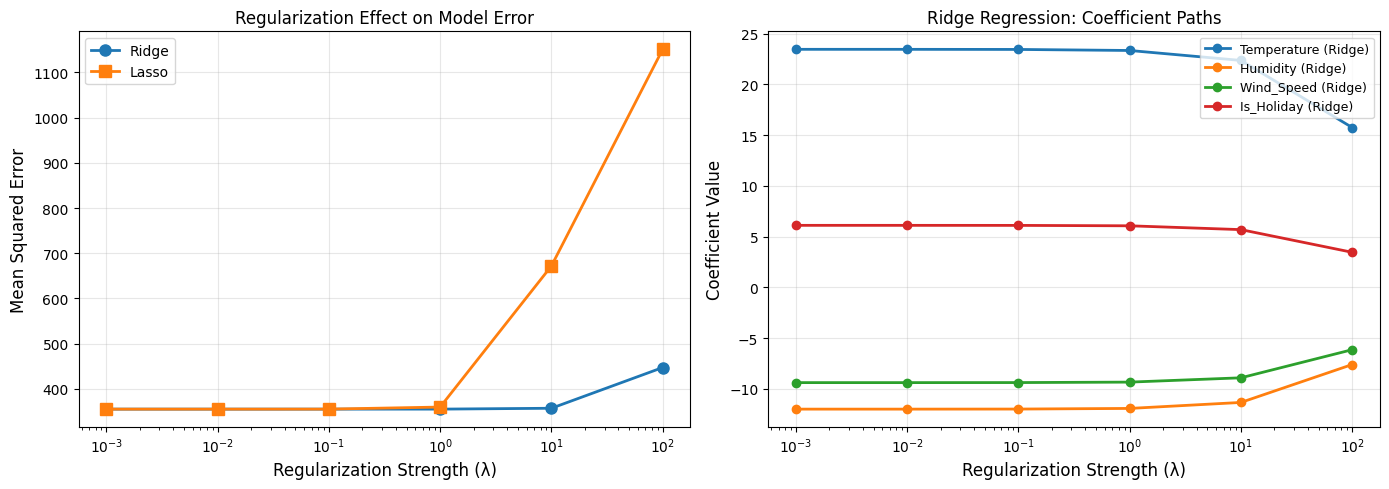

REGULARIZATION RESULTS

     Alpha       Ridge MSE       Lasso MSE
     0.001          355.20          355.20
     0.010          355.20          355.20
     0.100          355.20          355.25
     1.000          355.22          359.79
    10.000          357.13          671.93
   100.000          447.26         1151.22


In [5]:
# Standardize features for regularization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Test different regularization strengths
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

results = {'alpha': [], 'ridge_mse': [], 'lasso_mse': []}

for alpha in alphas:
    # Ridge regression
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_scaled, y)
    ridge_pred = ridge.predict(X_scaled)
    ridge_mse = mean_squared_error(y, ridge_pred)
    results['ridge_mse'].append(ridge_mse)

    # Lasso regression
    lasso = Lasso(alpha=alpha, max_iter=1000)
    lasso.fit(X_scaled, y)
    lasso_pred = lasso.predict(X_scaled)
    lasso_mse = mean_squared_error(y, lasso_pred)
    results['lasso_mse'].append(lasso_mse)

    results['alpha'].append(alpha)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE vs Lambda
axes[0].plot(alphas, results['ridge_mse'], 'o-', label='Ridge', linewidth=2, markersize=8)
axes[0].plot(alphas, results['lasso_mse'], 's-', label='Lasso', linewidth=2, markersize=8)
axes[0].set_xscale('log')
axes[0].set_xlabel('Regularization Strength (λ)', fontsize=12)
axes[0].set_ylabel('Mean Squared Error', fontsize=12)
axes[0].set_title('Regularization Effect on Model Error')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Coefficient paths
ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha).fit(X_scaled, y)
    ridge_coefs.append(ridge.coef_)
    lasso = Lasso(alpha=alpha, max_iter=1000).fit(X_scaled, y)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

for i in range(X.shape[1]):
    axes[1].plot(alphas, ridge_coefs[:, i], 'o-', label=f'{feature_names[i]} (Ridge)', linewidth=2)

axes[1].set_xscale('log')
axes[1].set_xlabel('Regularization Strength (λ)', fontsize=12)
axes[1].set_ylabel('Coefficient Value', fontsize=12)
axes[1].set_title('Ridge Regression: Coefficient Paths')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('REGULARIZATION RESULTS')
print('=' * 70)
print(f'\n{"Alpha":>10} {"Ridge MSE":>15} {"Lasso MSE":>15}')
for alpha, ridge_mse, lasso_mse in zip(alphas, results['ridge_mse'], results['lasso_mse']):
    print(f'{alpha:10.3f} {ridge_mse:15.2f} {lasso_mse:15.2f}')

## **5. Polynomial Regression**

Polynomial regression extends linear regression by including polynomial terms (squared, cubed, etc.) as features. This allows the model to capture non-linear relationships between predictors and the response.

For a single predictor x, polynomial regression fits:

y = β₀ + β₁x + β₂x² + β₃x³ + ... + βₚxᵖ + ε

This is still a linear model in terms of the coefficients, so least squares methods apply directly—we simply add polynomial terms as new columns in the design matrix.

### **Balancing Flexibility and Overfitting**

Higher-degree polynomials fit training data more closely but may overfit. The bias-variance tradeoff suggests:
- Low degree: High bias, low variance (underfitting)
- Moderate degree: Balance of bias and variance
- High degree: Low bias, high variance (overfitting)

Degree 1: Train R² = 0.6648, Val R² = 0.7817
Degree 2: Train R² = 0.6765, Val R² = 0.7627
Degree 3: Train R² = 0.7061, Val R² = 0.6885
Degree 4: Train R² = 0.7462, Val R² = 0.4360
Degree 5: Train R² = 0.8066, Val R² = 0.4976


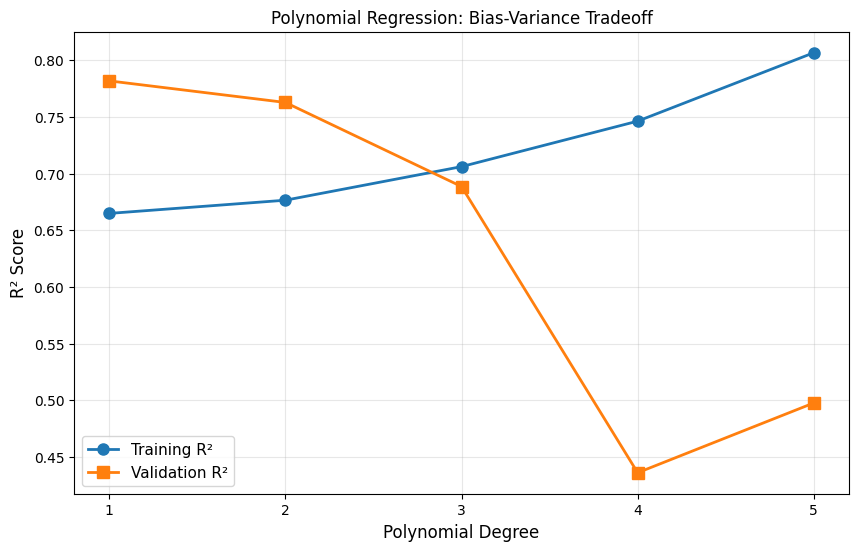


Optimal Degree Selection:
Best validation R²: 0.7817 at degree 1


In [6]:
# Test different polynomial degrees
degrees = [1, 2, 3, 4, 5]
train_scores = []
val_scores = []

# Split data
split = int(0.8 * len(X_scaled))
X_train, X_val = X_scaled[:split], X_scaled[split:]
y_train, y_val = y[:split], y[split:]

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    # Fit model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Score
    train_score = model.score(X_train_poly, y_train)
    val_score = model.score(X_val_poly, y_val)

    train_scores.append(train_score)
    val_scores.append(val_score)

    print(f'Degree {degree}: Train R² = {train_score:.4f}, Val R² = {val_score:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(degrees, train_scores, 'o-', label='Training R²', linewidth=2, markersize=8)
ax.plot(degrees, val_scores, 's-', label='Validation R²', linewidth=2, markersize=8)
ax.set_xlabel('Polynomial Degree', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Polynomial Regression: Bias-Variance Tradeoff')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees)
plt.show()

print('\nOptimal Degree Selection:')
optimal_idx = np.argmax(val_scores)
print(f'Best validation R²: {val_scores[optimal_idx]:.4f} at degree {degrees[optimal_idx]}')

## **6. Grid Search for Model Parameters**

Grid search systematically evaluates all combinations of model hyperparameters to find the optimal configuration. For regularized regression, we search over:
- **Regularization strength (λ)**: Controls the strength of the penalty
- **Model type**: Ridge, Lasso, or ElasticNet
- **Preprocessing**: Scaling, normalization

### **Cross-Validation**

To fairly evaluate models, we use k-fold cross-validation:
1. Split data into k folds
2. For each fold: train on k-1 folds, validate on 1 fold
3. Average validation scores across folds
4. Select model with best average score

This prevents overfitting to a single validation set and provides more reliable performance estimates.

In [7]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['auto']
}

# Ridge regression grid search
ridge_model = Ridge()
ridge_grid = GridSearchCV(ridge_model, param_grid, cv=5, scoring='r2')
ridge_grid.fit(X_scaled, y)

print('GRID SEARCH RESULTS')
print('=' * 70)
print('\nRidge Regression Grid Search:')
print(f'Best alpha: {ridge_grid.best_params_["alpha"]:.4f}')
print(f'Best CV R² Score: {ridge_grid.best_score_:.4f}')

# Cross-validation results
cv_results = ridge_grid.cv_results_
print(f'\nCross-Validation Results (5-fold):')
print(f'{"Alpha":>10} {"Mean CV R²":>15} {"Std":>12}')
for alpha, mean_score, std_score in zip(
    cv_results['param_alpha'],
    cv_results['mean_test_score'],
    cv_results['std_test_score']
):
    print(f'{alpha:10.4f} {mean_score:15.4f} {std_score:12.4f}')

# Get best model
best_model = ridge_grid.best_estimator_
y_pred_best = best_model.predict(X_scaled)
r2_best = r2_score(y, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y, y_pred_best))

print(f'\nBest Model Performance on Full Data:')
print(f'  R² Score: {r2_best:.4f}')
print(f'  RMSE: {rmse_best:.4f}')

GRID SEARCH RESULTS

Ridge Regression Grid Search:
Best alpha: 1.0000
Best CV R² Score: 0.6740

Cross-Validation Results (5-fold):
     Alpha      Mean CV R²          Std
    0.0010          0.6739       0.0589
    0.0100          0.6739       0.0588
    0.1000          0.6740       0.0588
    1.0000          0.6740       0.0582
   10.0000          0.6720       0.0531
  100.0000          0.5652       0.0316

Best Model Performance on Full Data:
  R² Score: 0.6914
  RMSE: 18.8474


## **7. Summary**

This chapter demonstrated practical applications of least squares methods to real-world prediction tasks:

**Bike Rental Prediction**: Used least squares regression to predict bike rental demand based on weather conditions, showing how domain knowledge translates to model design.

**Regression Statistics**: Interpreted regression tables including coefficients, standard errors, and p-values to understand model quality and statistical significance.

**Multicollinearity**: Detected correlated predictors using correlation matrices and Variance Inflation Factors, understanding how multicollinearity inflates parameter uncertainty.

**Regularization**: Applied Ridge, Lasso, and ElasticNet regression to address overfitting and multicollinearity by adding penalty terms to the least squares objective.

**Polynomial Regression**: Extended linear models with polynomial terms to capture non-linear relationships while managing the bias-variance tradeoff.

**Grid Search**: Systematically searched hyperparameter space using cross-validation to find optimal model configurations.

These techniques form the foundation for building robust predictive models in data science applications. The least squares framework, combined with regularization and careful model evaluation, enables practitioners to build models that generalize well to new data.